In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
plt.style.use("ggplot")
color_pal = sns.color_palette()

In [4]:
x = np.linspace(-3,3,1000)

In [5]:
x.shape

(1000,)

In [8]:
y = norm.pdf(x,0,1) # N(0,1)

In [13]:
samples = np.random.normal(0,1,1000)
samples.shape

(1000,)

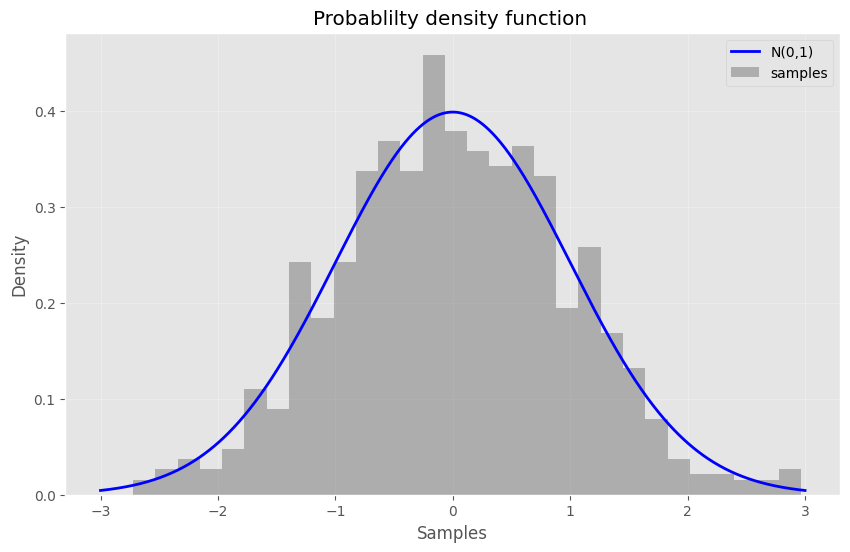

In [19]:
plt.figure(figsize=(10, 6))

# PDFs
plt.plot(x, y, 'b-', linewidth=2, label='N(0,1)') # the exact form of latent distribution
# Sample histograms (normalized)
plt.hist(samples, bins=30, density=True, alpha=0.5, color=color_pal[3], label='samples')
plt.xlabel('Samples')
plt.ylabel('Density')
plt.title('Probablilty density function ')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [21]:
cdf = norm.cdf(x,0,1)

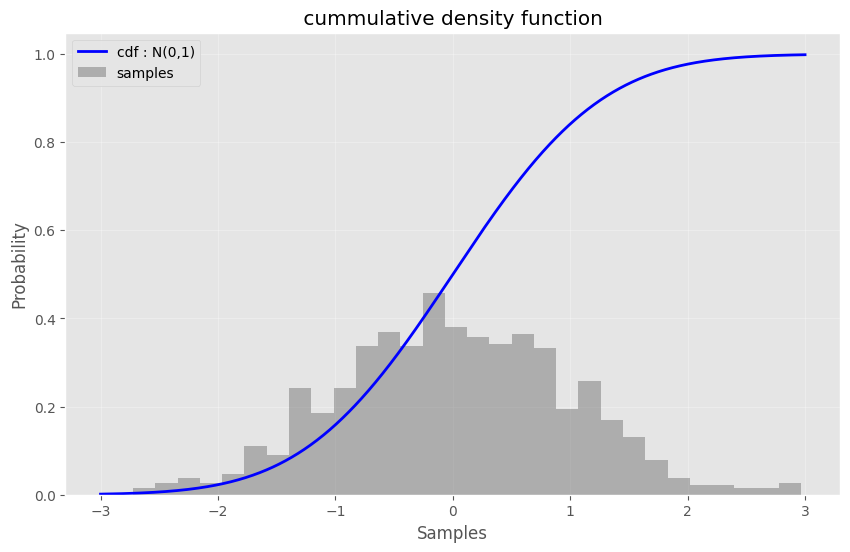

In [30]:
plt.figure(figsize=(10, 6))

# PDFs
plt.plot(x, cdf, 'b-', linewidth=2, label='cdf : N(0,1)') # the exact form of latent distribution
# Sample histograms (normalized)
plt.hist(samples, bins=30, density=True, alpha=0.5, color=color_pal[3], label='samples')
plt.xlabel('Samples')
plt.ylabel('Probability')
plt.title(' cummulative density function ')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

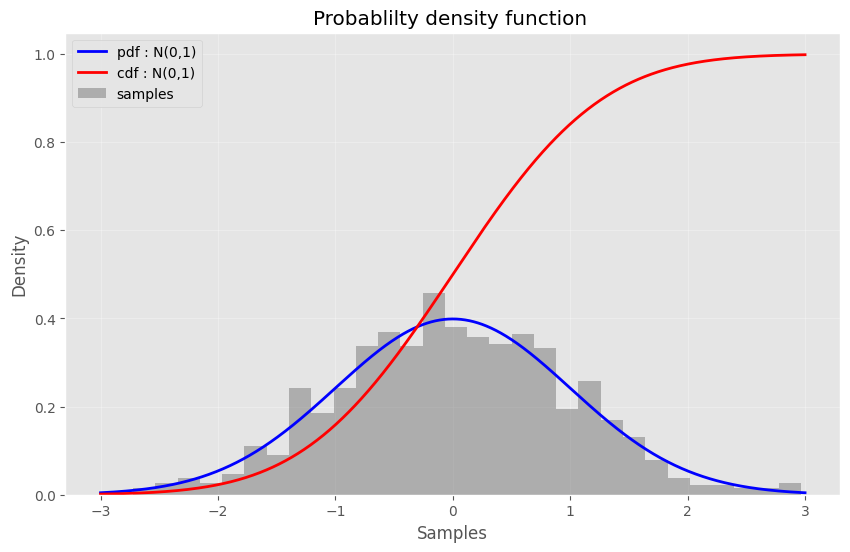

In [24]:
plt.figure(figsize=(10, 6))

# PDFs
plt.plot(x, y, 'b-', linewidth=2, label='pdf : N(0,1)')
plt.plot(x, cdf, 'r-', linewidth=2, label='cdf : N(0,1)')
# Sample histograms (normalized)
plt.hist(samples, bins=30, density=True, alpha=0.5, color=color_pal[3], label='samples')
plt.xlabel('Samples')
plt.ylabel('Density')
plt.title('Probablilty density function ')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [25]:
from scipy.integrate import quad

# Define PDF (e.g., standard normal)
pdf_func = norm.pdf

# Calculate CDF at a specific point x = 0
cdf_at_0, error = quad(pdf_func, -np.inf, 0)
print(f"CDF at 0: {cdf_at_0}") # Should be 0.5 for normal distribution

# because wvery standard normal as same value for cdf

CDF at 0: 0.4999999999999999


## Calculating Porbability Density

In [31]:
## How does the y axis value is calculated for the pdf (density)
## using kernal density estimator
from scipy.stats import gaussian_kde
kde = gaussian_kde(samples)

In [35]:
pdf_values = kde.evaluate(x)
pdf_values.shape

(1000,)

/tmp/ipython-input-1638725627.py:4: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(x, y, 'b-', linestyle= '--',linewidth=2, label='Original: N(0,1)')


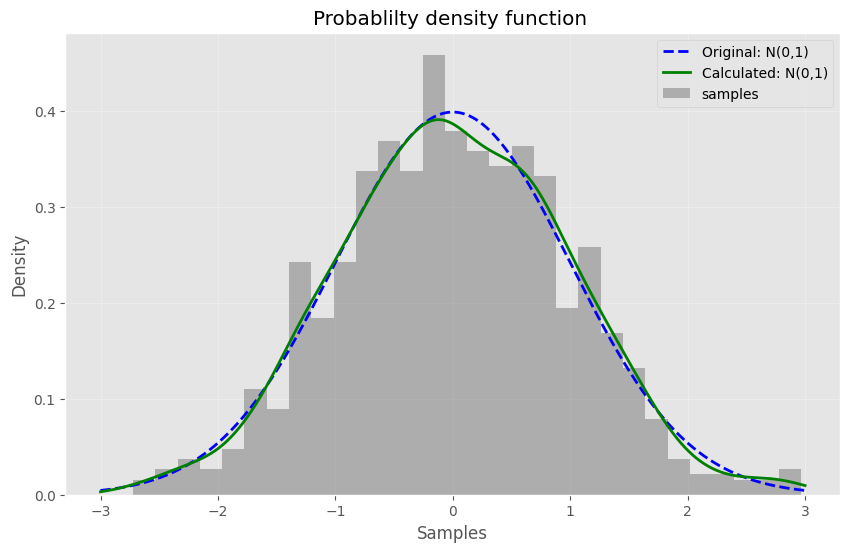

In [37]:
plt.figure(figsize=(10, 6))

# PDFs
plt.plot(x, y, 'b-', linestyle= '--',linewidth=2, label='Original: N(0,1)')
plt.plot(x,pdf_values,'g-',linewidth=2,label="Calculated: N(0,1)")
plt.hist(samples, bins=30, density=True, alpha=0.5, color=color_pal[3], label='samples')
plt.xlabel('Samples')
plt.ylabel('Density')
plt.title('Probablilty density function ')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()